# Objectifs

## Observe levels of protein in seaweed
### - Compare levels across different types of seaweed

### - Compare protein levels with other foods known for being high in protein 


# imports

In [12]:
# libraries

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt


from dotenv import load_dotenv
import os

load_dotenv(override=True) 



from lxml import etree # for importing other dataset that has 'alim_nom_fr' + 'ALIM_INDEX_FR' columns

# import dataset & check import

CIQUAL_DATA = os.getenv("CIQUAL_DATA")


df_ciqual = pd.read_excel(CIQUAL_DATA)



/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [13]:
df_ciqual.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),NaN,NaN,...,NaN,NaN,"1,37","0,084","0,15","0,61","0,4","0,056","30,8","0,21"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",NaN,-,...,-,-,"2,75","< 0,04","0,053","4,45","< 0,16","0,29",31,"1,45"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",NaN,-,...,"9,75",-,-,"0,032","0,022","4,13","0,2","0,12","11,1","1,23"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",NaN,-,...,-,-,"6,67","0,056","0,21","1,84","0,88","0,088","19,6","0,018"
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",NaN,-,...,-,-,10,"0,077","0,06","0,89","0,53","0,14",7,0


In [14]:
# NaN count
df_ciqual.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 76 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   alim_grp_code                                       3186 non-null   int64 
 1   alim_ssgrp_code                                     3186 non-null   int64 
 2   alim_ssssgrp_code                                   3186 non-null   int64 
 3   alim_grp_nom_eng                                    3141 non-null   object
 4   alim_ssgrp_nom_eng                                  3141 non-null   object
 5   alim_ssssgrp_nom_eng                                3141 non-null   object
 6   alim_code                                           3186 non-null   int64 
 7   alim_nom_eng                                        3186 non-null   object
 8   alim_nom_sci                                        270 non-null    object
 9   Energy, 

### Check for NaNs in Protein columns

In [15]:
df_ciqual[df_ciqual['Protein (g/100g)' or 'Protein, crude, N x 6.25 (g/100g)'].isnull()]


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
3146,10,1009,0,miscellaneous,miscellaneous ingredients for vegetarian,-,9621,Wheat bran,NaN,1160,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df_ciqual[df_ciqual['Protein, crude, N x 6.25 (g/100g)'].isnull()]


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
3146,10,1009,0,miscellaneous,miscellaneous ingredients for vegetarian,-,9621,Wheat bran,NaN,1160,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Create a DF to focus only on protein values

In [17]:
# list of columns to keep

# ID, food columns
id_columns = [
    "alim_grp_code",
    "alim_ssgrp_code",
    "alim_ssssgrp_code",
    "alim_grp_nom_eng",
    "alim_ssgrp_nom_eng",
    "alim_ssssgrp_nom_eng",
    "alim_code",
    "alim_nom_eng",
    ]

# protein columns
protein_columns = [
    "Protein (g/100g)",
    "Protein, crude, N x 6.25 (g/100g)"
    ]


df_protein = df_ciqual[id_columns + protein_columns]

df_protein.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)"
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),"4,63","4,61"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned","9,15","9,15"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad","8,06","8,06"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked","2,08","2,08"
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made","2,68","2,68"


In [18]:
df_protein[df_protein['Protein (g/100g)' or 'Protein, crude, N x 6.25 (g/100g)'].isnull()]


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)"
3146,10,1009,0,miscellaneous,miscellaneous ingredients for vegetarian,-,9621,Wheat bran,NaN,NaN


In [19]:
df_protein.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   alim_grp_code                      3186 non-null   int64 
 1   alim_ssgrp_code                    3186 non-null   int64 
 2   alim_ssssgrp_code                  3186 non-null   int64 
 3   alim_grp_nom_eng                   3141 non-null   object
 4   alim_ssgrp_nom_eng                 3141 non-null   object
 5   alim_ssssgrp_nom_eng               3141 non-null   object
 6   alim_code                          3186 non-null   int64 
 7   alim_nom_eng                       3186 non-null   object
 8   Protein (g/100g)                   3185 non-null   object
 9   Protein, crude, N x 6.25 (g/100g)  3185 non-null   object
dtypes: int64(4), object(6)
memory usage: 249.0+ KB


In [20]:
pd.set_option('display.max_rows', None)

In [21]:
df_protein.value_counts(protein_columns)

Protein (g/100g)  Protein, crude, N x 6.25 (g/100g)
0                 0                                    178
< 0,5             < 0,5                                 70
0,63              0,63                                  20
-                 -                                     18
1,13              1,13                                  15
1,1               1,1                                   14
19                19                                    14
10,3              10,3                                  14
0,69              0,69                                  14
0,75              0,75                                  13
18                18                                    13
23                23                                    13
1                 1                                     13
0,94              0,94                                  12
18,3              18,3                                  12
18,8              18,8                                  12
0,5 

In [22]:
df_protein_missing = df_protein[(df_protein[protein_columns] == '-').any(axis=1)]
df_protein_missing


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)"
604,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20801,"Pumpkin (local variety), crisps, sampled in th...",-,-
605,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20802,"Pumpkin (phoenix variety), crisps, sampled in ...",-,-
609,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20806,"Chayote, white skin, pulp, canned, not drained...",-,-
610,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20807,"Chayote, white skin, pulp, steamed, frozen, sa...",-,-
615,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20812,"Sweet potatoe flour, sampled in the island of ...",-,-
618,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20815,"Pumpkin (local variety), pulp, steamed, frozen...",-,-
619,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20816,"local variety), pulp, grated, raw, sampled in ...",-,-
621,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20818,"Pumpkin (phoenix variety), pulp, grated, raw, ...",-,-
622,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20819,"Pumpkin (phoenix variety), pulp, frozen, steam...",-,-
623,2,201,20104,"fruits, vegetables, legumes and nuts",vegetables,vegetables from Martinique and their products,20820,"Okra, whole, canned, not drained, sampled in t...",-,-


## Handle columns with "<" values

In [23]:
# Initialize a boolean mask DataFrame to track which protein cells start with "< "
approx_mask = pd.DataFrame(False, index=df_protein.index, columns=protein_columns)

# Iterate through each protein column to identify and process approximate values
for col in protein_columns:
   
    # Convert column to string and strip whitespace for consistent pattern matching 
    col_str = df_protein[col].astype(str).str.strip()
    col_str = col_str.str.replace(",", ".", regex=False)
    
    # Identify cells that start with "< ", indicating an approximate value
    is_approx = col_str.str.startswith("< ")

    # Update the mask with True where "< " is detected in this column
    approx_mask[col] = is_approx


    # Extract the numeric part from entries like "< 0.3", convert to float, 
    # and apply a 0.75 multiplier    # Step 6: Apply 0.75 multiplier for approximations
    
    # This assumes the true value is ~75% of the detection limit
    df_protein.loc[is_approx, col] = pd.to_numeric(
    df_protein.loc[is_approx, col].str.extract(r"<\s*([\d\.]+)")[0],
    errors='coerce'
    ) * 0.75

# Explicitly set values using .loc[] to avoid SettingWithCopyWarning

# Add a new column that flags rows containing any "< " value in protein columns
df_protein.loc[:, "contains_less_than"] = approx_mask.any(axis=1)

# Add another column counting how many "< " values were approximated per row
df_protein.loc[:, "approx_count"] = approx_mask.sum(axis=1)


/var/folders/kl/2y01c7y51cj42bdww37cvc5c0000gn/T/ipykernel_77432/1991115897.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_protein.loc[:, "contains_less_than"] = approx_mask.any(axis=1)
/var/folders/kl/2y01c7y51cj42bdww37cvc5c0000gn/T/ipykernel_77432/1991115897.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_protein.loc[:, "approx_count"] = approx_mask.sum(axis=1)


## Handle "hidden" NaNs and values like "traces"

In [24]:
# Define custom replacements
replacement_map = {
    ",": ".",
    "traces": "0.000001",
    "-": np.nan,
    "nan": np.nan,
    "NaN": np.nan,
    "NAN": np.nan,
    "None": np.nan,
    "": np.nan,
}

# Work on a copy to avoid SettingWithCopyWarning
df_protein = df_protein.copy()

# Replace string-based irregular entries
df_protein[protein_columns] = (
    df_protein[protein_columns]
    .astype(str)
    .replace(replacement_map, regex=False)
)

# Replace commas inside string values with dots
df_protein[protein_columns] = (
    df_protein[protein_columns]
    .map(lambda x: x.replace(",", ".") if isinstance(x, str) else x)
    )

# Convert the cleaned-up strings to float
df_protein[protein_columns] = df_protein[protein_columns].astype(float)


In [25]:
df_protein.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)",contains_less_than,approx_count
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),4.63,4.61,False,0
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",9.15,9.15,False,0
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",8.06,8.06,False,0
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",2.08,2.08,False,0
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",2.68,2.68,False,0


In [26]:
df_protein.isnull().sum()


alim_grp_code                         0
alim_ssgrp_code                       0
alim_ssssgrp_code                     0
alim_grp_nom_eng                     45
alim_ssgrp_nom_eng                   45
alim_ssssgrp_nom_eng                 45
alim_code                             0
alim_nom_eng                          0
Protein (g/100g)                     19
Protein, crude, N x 6.25 (g/100g)    19
contains_less_than                    0
approx_count                          0
dtype: int64

In [27]:
df_protein.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   alim_grp_code                      3186 non-null   int64  
 1   alim_ssgrp_code                    3186 non-null   int64  
 2   alim_ssssgrp_code                  3186 non-null   int64  
 3   alim_grp_nom_eng                   3141 non-null   object 
 4   alim_ssgrp_nom_eng                 3141 non-null   object 
 5   alim_ssssgrp_nom_eng               3141 non-null   object 
 6   alim_code                          3186 non-null   int64  
 7   alim_nom_eng                       3186 non-null   object 
 8   Protein (g/100g)                   3167 non-null   float64
 9   Protein, crude, N x 6.25 (g/100g)  3167 non-null   float64
 10  contains_less_than                 3186 non-null   bool   
 11  approx_count                       3186 non-null   int64

In [28]:
# remove rows with NaN values in either Protein columns
df_protein_filtered = df_protein.dropna(subset=protein_columns)

print(df_protein_filtered.isnull().sum(), "\n")

df_protein_filtered.info(show_counts=True)


alim_grp_code                         0
alim_ssgrp_code                       0
alim_ssssgrp_code                     0
alim_grp_nom_eng                     45
alim_ssgrp_nom_eng                   45
alim_ssssgrp_nom_eng                 45
alim_code                             0
alim_nom_eng                          0
Protein (g/100g)                      0
Protein, crude, N x 6.25 (g/100g)     0
contains_less_than                    0
approx_count                          0
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
Index: 3167 entries, 0 to 3185
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   alim_grp_code                      3167 non-null   int64  
 1   alim_ssgrp_code                    3167 non-null   int64  
 2   alim_ssssgrp_code                  3167 non-null   int64  
 3   alim_grp_nom_eng                   3122 non-null   object 
 4   alim_ssgrp_nom

In [29]:
df_protein_filtered[df_protein_filtered.isnull().any(axis=1)]

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)",contains_less_than,approx_count
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),4.63,4.61,False,0
1097,3,305,30501,NaN,NaN,NaN,4090,Potato starch,0.00,0.00,False,0
1098,3,305,30501,NaN,NaN,NaN,9311,Oatmeal flakes,13.30,14.20,False,0
1099,3,305,30501,NaN,NaN,NaN,9410,"Wheat flour, type 110",9.61,10.30,False,0
1100,3,305,30501,NaN,NaN,NaN,9415,"Wheat flour, type 150",11.40,12.20,False,0
1101,3,305,30501,NaN,NaN,NaN,9435,"Wheat flour, type 65",13.60,14.90,False,0
1102,3,305,30501,NaN,NaN,NaN,9436,"Wheat flour, type 55 (for bread)",9.03,9.90,False,0
1103,3,305,30501,NaN,NaN,NaN,9437,"Wheat flour, self-raising",9.12,10.00,False,0
1104,3,305,30501,NaN,NaN,NaN,9440,"Wheat flour, type 55 (for pastry)",9.06,9.94,False,0
1105,3,305,30501,NaN,NaN,NaN,9445,"Wheat flour, type 80",9.95,10.90,False,0


In [30]:
df_protein_filtered.value_counts(protein_columns)

Protein (g/100g)  Protein, crude, N x 6.25 (g/100g)
0.000000          0.000000                             259
0.630000          0.630000                              20
1.130000          1.130000                              15
10.300000         10.300000                             14
0.690000          0.690000                              14
19.000000         19.000000                             14
1.100000          1.100000                              14
18.000000         18.000000                             13
0.750000          0.750000                              13
1.000000          1.000000                              13
23.000000         23.000000                             13
0.500000          0.500000                              12
18.300000         18.300000                             12
18.800000         18.800000                             12
0.940000          0.940000                              12
0.880000          0.880000                              11
16.3

In [31]:
df_protein_filtered.columns

Index(['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng', 'Protein (g/100g)',
       'Protein, crude, N x 6.25 (g/100g)', 'contains_less_than',
       'approx_count'],
      dtype='object')

## Update dataset to add more details about types of seaweed (red, brown, green or microalgae)

In [32]:
df_protein_filtered = df_protein_filtered.copy()

# function to add a new column with more details about seaweed subgroup
def categorize_seaweed(name):
    name = name.lower()
    if "spirulina" in name:
        return "microalgae"
    elif any(term in name for term in ["agar", "porphyra", "dulse", "gracilaria", "chondrus"]):
        return "red seaweed"
    elif any(term in name for term in ["ulva", "enteromorpha", "sea lettuce"]):
        return "green seaweed"
    elif any(term in name for term in [
        "wakame", "undaria", "saccharina", "kelp", "kombu", "laminaria",
        "himanthalia", "fucus", "ascophyllum", "alaria"
    ]):
        return "brown seaweed"
    else:
        return "unknown"
    

df_protein_filtered["seaweed_type"] = df_protein_filtered["alim_nom_eng"].apply(categorize_seaweed)


In [33]:
# reorganize columns for clarity
df_protein_cleaned = df_protein_filtered[['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'seaweed_type', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng', 'Protein (g/100g)',
       'Protein, crude, N x 6.25 (g/100g)', 'contains_less_than',
       'approx_count']]

df_protein_cleaned.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,seaweed_type,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)",contains_less_than,approx_count
0,0,0,0,NaN,NaN,unknown,NaN,24999,Desert (average),4.63,4.61,False,0
1,1,101,0,starters and dishes,mixed salads,unknown,-,25601,"Prepared mixed tuna and vegetable salad, canned",9.15,9.15,False,0
2,1,101,0,starters and dishes,mixed salads,unknown,-,25602,"Prepared mixed meat/fish canned, salad",8.06,8.06,False,0
3,1,101,0,starters and dishes,mixed salads,unknown,-,25605,"Greek-style marinated mushrooms, prepacked",2.08,2.08,False,0
4,1,101,0,starters and dishes,mixed salads,unknown,-,25606,"Prepared potatoes salad, home-made",2.68,2.68,False,0


## Filter df to only select seaweeds and meat colums

In [34]:
df_protein_cleaned.value_counts("alim_ssgrp_nom_eng")

alim_ssgrp_nom_eng
vegetables                               292
delicatessen meat and similar            173
fruits                                   168
raw meat                                 162
dishes                                   159
non-alcoholic beverages                  156
dairy products and similar               137
cheese and similar                       134
cooked meat                              133
fish, raw                                106
water                                     90
cakes and pastry                          85
sauces                                    75
pasta, rice and grains                    70
sweet biscuits                            65
fish, cooked                              63
fish products                             56
breads and similar                        56
nuts and seeds                            52
potatoes and other tubers                 51
alcoholic beverages                       49
breakfast cereals                   

In [35]:
keywords = "seaweed|meat|fish|egg"
df_seaweed_like = df_protein_cleaned[
    df_protein_cleaned["alim_ssgrp_nom_eng"].str.contains(keywords, case=False, na=False)
]

df_seaweed_like.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760 entries, 1141 to 3114
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   alim_grp_code                      760 non-null    int64  
 1   alim_ssgrp_code                    760 non-null    int64  
 2   alim_ssssgrp_code                  760 non-null    int64  
 3   alim_grp_nom_eng                   760 non-null    object 
 4   alim_ssgrp_nom_eng                 760 non-null    object 
 5   seaweed_type                       760 non-null    object 
 6   alim_ssssgrp_nom_eng               760 non-null    object 
 7   alim_code                          760 non-null    int64  
 8   alim_nom_eng                       760 non-null    object 
 9   Protein (g/100g)                   760 non-null    float64
 10  Protein, crude, N x 6.25 (g/100g)  760 non-null    float64
 11  contains_less_than                 760 non-null    bool   


### Observe foods known for having high protein counts

In [36]:
# observe foods with highest protein counts
df_seaweed_like.sort_values(by="Protein (g/100g)", ascending=False)


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,seaweed_type,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)",contains_less_than,approx_count
1915,4,410,41003,"meat, egg and fish",eggs,unknown,omelettes and other egg products,22004,"Egg white, powder",81.20,81.20,False,0
3100,10,1007,0,miscellaneous,seaweed,microalgae,-,11086,"Spirulina, (spirulina sp.), dried",57.50,57.50,False,0
1916,4,410,41003,"meat, egg and fish",eggs,unknown,omelettes and other egg products,22013,"Egg, powder",47.90,47.90,False,0
1724,4,406,0,"meat, egg and fish","fish, raw",unknown,-,26098,"Cod, salted, dried",47.60,47.60,False,0
1152,4,401,40101,"meat, egg and fish",cooked meat,unknown,beef and veal,6141,"Beef, cheek, braised or boiled",39.20,39.20,False,0
1581,4,403,40308,"meat, egg and fish",delicatessen meat and similar,unknown,other delicatessen,28860,Viande des Grisons or Bündnerfleisch or dried ...,38.90,38.90,False,0
1182,4,401,40101,"meat, egg and fish",cooked meat,unknown,beef and veal,6581,"Veal, knuckle or shank, braised or boiled",37.40,37.40,False,0
1150,4,401,40101,"meat, egg and fish",cooked meat,unknown,beef and veal,6123,"Beef, short ribs, braised",37.30,37.30,False,0
1189,4,401,40102,"meat, egg and fish",cooked meat,unknown,pork,28103,"Pork, round steak, cooked",36.90,36.90,False,0
1170,4,401,40101,"meat, egg and fish",cooked meat,unknown,beef and veal,6271,"Beef, chuck, braised or boiled",36.80,36.80,False,0


## Dataviz

In [37]:
pd.set_option('display.max_colwidth', None)

In [38]:
# create a df that only contains seaweeds
df_seaweed = df_seaweed_like[
    df_seaweed_like["alim_ssgrp_nom_eng"].str.contains("seaweed", case=False)
]
df_seaweed["alim_nom_eng"]

3098                                                                     Seaweed, agar, raw
3099                                                                   Seaweed, agar, dried
3100                                                      Spirulina, (spirulina sp.), dried
3101                                      Wakame (Undaria pinnatifida), dried or dehydrated
3102                                           Sea lettuce (ulva sp.), dried or dehydrated)
3103                                   Sea belt (Saccharina latissima), dried or dehydrated
3104                                              Laver (Porphyra sp.), dried or dehydrated
3105                                          Dulse (Palmaria palmata), dried or dehydrated
3106                       Kombu or Japanese kelp (Laminaria japonica), dried or dehydrated
3107                                       Tangle (Laminaria digitata), dried or dehydrated
3108                                  Sea thong (Himanthalia elongata), dried or

In [39]:
df_seaweed

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,seaweed_type,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)",contains_less_than,approx_count
3098,10,1007,0,miscellaneous,seaweed,red seaweed,-,11084,"Seaweed, agar, raw",0.54,0.54,False,0
3099,10,1007,0,miscellaneous,seaweed,red seaweed,-,11085,"Seaweed, agar, dried",4.36,4.36,False,0
3100,10,1007,0,miscellaneous,seaweed,microalgae,-,11086,"Spirulina, (spirulina sp.), dried",57.50,57.50,False,0
3101,10,1007,0,miscellaneous,seaweed,brown seaweed,-,20984,"Wakame (Undaria pinnatifida), dried or dehydrated",14.10,14.10,False,0
3102,10,1007,0,miscellaneous,seaweed,green seaweed,-,20985,"Sea lettuce (ulva sp.), dried or dehydrated)",15.90,15.90,False,0
3103,10,1007,0,miscellaneous,seaweed,brown seaweed,-,20986,"Sea belt (Saccharina latissima), dried or dehydrated",10.30,10.30,False,0
3104,10,1007,0,miscellaneous,seaweed,red seaweed,-,20987,"Laver (Porphyra sp.), dried or dehydrated",31.50,31.50,False,0
3105,10,1007,0,miscellaneous,seaweed,red seaweed,-,20988,"Dulse (Palmaria palmata), dried or dehydrated",17.20,17.20,False,0
3106,10,1007,0,miscellaneous,seaweed,brown seaweed,-,20990,"Kombu or Japanese kelp (Laminaria japonica), dried or dehydrated",8.38,8.38,False,0
3107,10,1007,0,miscellaneous,seaweed,brown seaweed,-,20991,"Tangle (Laminaria digitata), dried or dehydrated",9.51,9.51,False,0


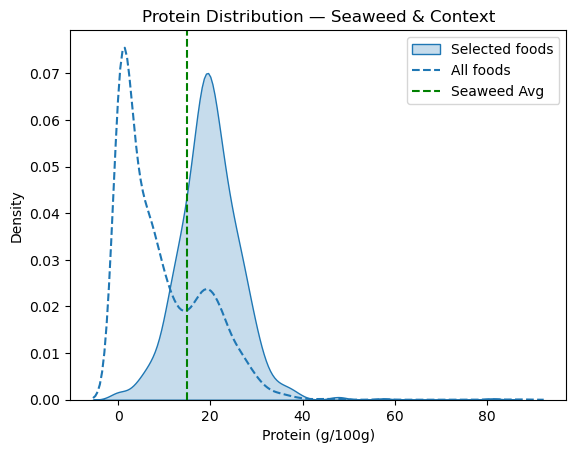

In [40]:
sns.kdeplot(data=df_seaweed_like, x="Protein (g/100g)", label="Selected foods", fill=True)
sns.kdeplot(data=df_protein, x="Protein (g/100g)", label="All foods", linestyle="--")
plt.axvline(df_seaweed["Protein (g/100g)"].mean(), color="green", linestyle="--", label="Seaweed Avg")
plt.legend()
plt.title("Protein Distribution — Seaweed & Context")
plt.xlabel("Protein (g/100g)")
plt.show()


In [41]:
# Sort descending
df_sorted_desc = df_protein_cleaned.sort_values(by="Protein (g/100g)", ascending=False)
df_sorted_desc.head(10)

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,seaweed_type,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)",contains_less_than,approx_count
3126,10,1009,0,miscellaneous,miscellaneous ingredients,unknown,-,11007,"Gelatine, dried",86.9,86.9,False,0
1915,4,410,41003,"meat, egg and fish",eggs,unknown,omelettes and other egg products,22004,"Egg white, powder",81.2,81.2,False,0
3100,10,1007,0,miscellaneous,seaweed,microalgae,-,11086,"Spirulina, (spirulina sp.), dried",57.5,57.5,False,0
1916,4,410,41003,"meat, egg and fish",eggs,unknown,omelettes and other egg products,22013,"Egg, powder",47.9,47.9,False,0
1724,4,406,0,"meat, egg and fish","fish, raw",unknown,-,26098,"Cod, salted, dried",47.6,47.6,False,0
3032,10,1003,0,miscellaneous,cooking aids,unknown,-,11175,"Madeira wine aspic, dehydrated",44.5,44.5,False,0
3129,10,1009,0,miscellaneous,miscellaneous ingredients,unknown,-,11045,"Baker's yeast, dehydrated",44.5,44.5,False,0
3127,10,1009,0,miscellaneous,miscellaneous ingredients,unknown,-,11009,Nutritional yeast,40.4,40.4,False,0
1152,4,401,40101,"meat, egg and fish",cooked meat,unknown,beef and veal,6141,"Beef, cheek, braised or boiled",39.2,39.2,False,0
1581,4,403,40308,"meat, egg and fish",delicatessen meat and similar,unknown,other delicatessen,28860,Viande des Grisons or Bündnerfleisch or dried beef meat,38.9,38.9,False,0


In [42]:
# check for hidden NaNs

df_protein[protein_columns] = df_protein[(df_protein[protein_columns] == '-').any(axis=1)].copy().replace('-', np.nan)


df_protein_missing.info()


ValueError: Columns must be same length as key

# Manage columns with "<" symbols 

In [ ]:
df_protein[df_protein[protein_columns].apply(lambda row: row.astype(str).str.contains("< ").any(), axis=1)]


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,Protein (g/100g),"Protein, crude, N x 6.25 (g/100g)"
563,2,201,20102,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, cooked",20306,"Carrot, boiled/cooked in water, tender","< 0,5","< 0,5"
574,2,201,20102,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, cooked",20317,"Fennel, braised","< 0,5","< 0,5"
588,2,201,20102,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, cooked",20332,"Pumpkin, roasted/baked","< 0,5","< 0,5"
731,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13002,"Pineapple, pulp, raw","< 0,5","< 0,5"
735,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13009,"Lemon, pulp, raw","< 0,5","< 0,5"
758,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13040,"Grapefruit, pulp, raw","< 0,5","< 0,5"
776,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13086,"Apple, var. Golden, pulp, raw","< 0,5","< 0,5"
783,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13121,"Apple, var. Granny Smith, pulp, raw","< 0,5","< 0,5"
784,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13122,"Apple, var. Granny Smith, pulp and skin, raw","< 0,5","< 0,5"
795,2,204,20401,"fruits, vegetables, legumes and nuts",fruits,fresh fruits,13188,"Pear, var. Conférence, pulp, raw","< 0,5","< 0,5"


## Function to handle values starting with "< " 

In [ ]:
def flag_and_adjust_approximations(df, columns, multiplier=0.75):
    # Create a copy to avoid modifying the original DataFrame directly
    df = df.copy()

    # Initialize a mask to track where approximation values occur
    approx_mask = pd.DataFrame(False, index=df.index, columns=columns)

    for col in columns:
        # Standardize the column as string and remove leading/trailing spaces
        col_str = df[col].astype(str).str.strip()

        # Identify cells beginning with "< "
        is_approx = col_str.str.startswith("< ")

        # Update the mask using .loc to avoid SettingWithCopyWarning
        approx_mask.loc[:, col] = is_approx

        # Extract numeric part from approximated values and apply the multiplier
        extracted_vals = col_str.str.extract(r"<\s*([\d\.]+)")[0]
        numeric_vals = pd.to_numeric(extracted_vals, errors='coerce')

        # Assign transformed values back to the DataFrame using .loc
        df.loc[is_approx, col] = numeric_vals * multiplier

    # Safely assign metadata columns using .loc
    df.loc[:, "contains_less_than"] = approx_mask.any(axis=1)
    df.loc[:, "approx_count"] = approx_mask.sum(axis=1)

    return df
